In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv(r'C:\Users\Nigar\Downloads\nobel_latest.csv',delimiter=',',header=0,encoding='UTF8')

In [5]:
df

,Year,Laureate_Id,Firstname,Lastname,Category,Gender,Prize_Share,Motivation,Birth_Date,Birth_Country,Birth_City,Birth_Country_Code,Death_Date,Death_Country,Death_City,Death_Country_Code,Organization_Name,Organization_City,Organization_Country
0,1901,1,Wilhelm Conrad,Röntgen,physics,male,1,"""in recognition of the extraordinary services ...",1845-03-27,Prussia (now Germany),Lennep (now Remscheid),DE,10-02-1923,Germany,Munich,DE,Munich University,Munich,Germany
1,1901,293,Emil,von Behring,medicine,male,1,"""for his work on serum therapy especially its ...",1854-03-15,Prussia (now Poland),Hansdorf (now Lawice),PL,31-03-1917,Germany,Marburg,DE,Marburg University,Marburg,Germany
2,1901,462,Henry,Dunant,peace,male,2,"""for his humanitarian efforts to help wounded ...",1828-05-08,Switzerland,Geneva,CH,30-10-1910,Switzerland,Heiden,CH,NaN,NaN,NaN
3,1901,463,Frédéric,Passy,peace,male,2,"""for his lifelong work for international peace...",1822-05-20,France,Paris,FR,12-06-1912,France,Paris,FR,NaN,NaN,NaN
4,1901,569,Sully,Prudhomme,literature,male,1,"""in special recognition of his poetic composit...",1839-03-16,France,Paris,FR,07-09-1907,France,Châtenay,FR,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
984,2022,1011,Svante,Pääbo,medicine,male,1,"""for his discoveries concerning the genomes of...",20-04-1955,Sweden,Stockholm,SE,0000-00-00,NaN,NaN,NaN,Max Planck Institute for Evolutionary Anthropo...,Leipzig,Germany
985,2022,743,Barry,Sharpless,chemistry,male,3,"""for the development of click chemistry and bi...",28-04-1941,USA,Philadelphia PA,US,0000-00-00,NaN,NaN,NaN,Scripps Research,La Jolla CA,USA
986,2022,1022,Douglas,Diamond,economics,male,3,"""for research on banks and financial crises""",25-10-1953,USA,Chicago IL,US,0000-00-00,NaN,NaN,NaN,University of Chicago,Chicago IL,USA
987,2022,1015,Carolyn,Bertozzi,chemistry,female,3,"""for the development of click chemistry and bi...",10-10-1966,USA,Boston MA,US,0000-00-00,NaN,NaN,NaN,Stanford University,Stanford CA,USA


In [78]:
#1.	(5) / Datada cəmi neçə laureat verilib?
df['Laureate_Id'].count()
df['Laureate_Id'].nunique()

981

In [129]:
#2.	(10) / Ən çox hansı ildə Nobel laureatı verilib? Top 10 tapın və barchart vasitəsilə vizuallaşdırın.
b=df['Year'].value_counts().head(10).reset_index()
b

,Year,count
0,2001,15
1,2022,14
2,2019,14
3,2013,13
4,1996,13
5,2000,13
6,2005,13
7,2009,13
8,2011,13
9,2002,13


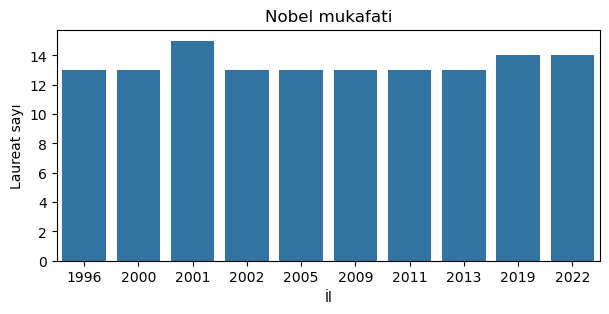

In [85]:
plt.figure(figsize=(7,3))
sns.barplot(x='Year', y='count',data=a)
plt.title("Nobel mukafati")
plt.xlabel("İl")
plt.ylabel("Laureat sayı")
plt.show()

In [131]:
#3.	(10) / Birdən çox Nobel laureatı olan adam və ya topluluq var? Onlar neçə nəfərdirlər? Ən çox alan kimdir və neçə laureat alıb?
c= df['Laureate_Id'].value_counts().reset_index()
print(c[c['count']>1])
print('en cox alan:',c.head(1))

   Laureate_Id  count
0          482      3
1          217      2
2          222      2
3          515      2
4           66      2
5          743      2
6            6      2
en cox alan:    Laureate_Id  count
0          482      3


In [27]:
#4.	(15) / Hansı kateqoriya üzrə laureatlar neçə dənədir? Bunu vizuallaşdırın, amma bu vizuala eyni zamanda bir məlumatda əlavə edin – Gender. Yəni hansı kateqoriya üzrə hansı gender nümayəndələri nə qədər laureata layiq görülüblər? Eyni zamanda bu pivotlaşdırmanı (qruplaşdırma) kodla da həyata keçirind
pd.pivot_table(df,index='Category',values='Laureate_Id',columns='Gender',aggfunc='count')

Gender,female,male,org
Category,,,
chemistry,8.0,183.0,NaN
economics,2.0,90.0,NaN
literature,17.0,102.0,NaN
medicine,12.0,213.0,NaN
peace,18.0,92.0,30.0
physics,4.0,218.0,NaN


<Axes: xlabel='Category', ylabel='count'>

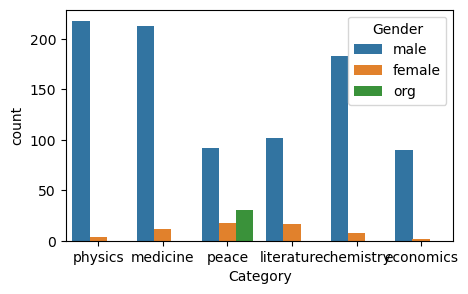

In [95]:
plt.figure(figsize = (5,3))
sns.countplot(x = 'Category', data = df, hue = 'Gender')

In [133]:
#5.	(5) / Kişilər/qadınlar/topluluqlar olaraq ortalama neçə nəfər laureat alırlar? (Prize_Share). 
d=df.groupby('Gender')['Prize_Share'].mean().reset_index()
d

,Gender,Prize_Share
0,female,1.983607
1,male,2.045657
2,org,1.466667


In [101]:
#6.	(10) / Motivation sütununda dırnaq işarələrini yığışdıran kodu yazın.
df['Motivation']=df['Motivation'].str.replace('"','')
df['Motivation']

AttributeError: Can only use .str accessor with string values!

In [65]:
#7.	(20) / Birth_Date sütununda laureatların doğum tarixləri verilmişdir. Həmin sütunu ayıraraq, yeni bir sütun yaradın (Birth_year adında). Ən çox hansı əsrdə doğulan elm adamları bu ödülü aldığını göstərən kodları yazın.
df['Birth_year']=pd.to_datetime(df['Birth_Date'],errors='coerce').dt.year
df['Century']=(df['Birth_year']//100+1)
df['Century'].value_counts()

Century
19.0    286
Name: count, dtype: int64

In [103]:
df['Birth_year']=pd.to_datetime(df['Birth_Date'],errors='coerce').dt.year

def esr(year):
    if pd.isna(year):
        return 'melum olmayanlar'
    elif year < 1900:
        return 'XIX əsr'
    elif year < 2000:
        return 'XX əsr'
    else:
        return 'XXI əsr'

df['Esr'] = df['Birth_year'].apply(esr)


print(df.groupby('Esr')['Laureate_Id'].count())

Esr
XIX əsr             286
melum olmayanlar    703
Name: Laureate_Id, dtype: int64


In [106]:
#8.	(10) / Laureata layiq görülən əməkdaşlar ən çox hansı ölkədən olub? Bu məlumatı vizuallaşdırın.
a=df['Birth_Country'].value_counts().reset_index().head(10)
a

,Birth_Country,count
0,USA,289
1,United Kingdom,90
2,Germany,67
3,France,56
4,Sweden,30
5,Japan,28
6,Canada,21
7,Switzerland,19
8,the Netherlands,19
9,Russia,18


In [69]:
df.groupby('Birth_Country')['Laureate_Id'].count().sort_values(ascending = False).reset_index()

,Birth_Country,Laureate_Id
0,USA,289
1,United Kingdom,90
2,Germany,67
3,France,56
4,Sweden,30
...,...,...
121,Mecklenburg (now Germany),1
122,Madagascar,1
123,Lithuania,1
124,Lebanon,1


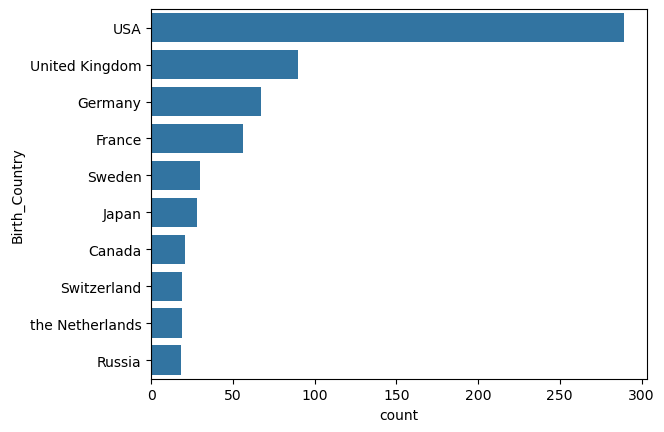

In [107]:
sns.barplot(y='Birth_Country',x='count',data=a)
plt.show()

In [124]:
#9.	(15) / Death_date sütununda elm adamlarının öldüyü tarixi göstərir. Əgər bir elm adamı deyil topluluqdursa, Death_date “0000-00-00” kimi göstərir. Əgər elm adamıdırsa, və “0000-00-00” kimi görünürsə, deməli adam hələ də yaşayır. İndi sizdən istənilən məlumat, neçə nəfər laureat ölüb və neçəsi hələ də yaşayır? org gender-a sahib sətrlər sayılmamalıdır.
def yasayaninsansayi(df):
    insanlar=df[df['Gender']!='org']
    yasayanlar=insanlar['Death_Date']=='0000-00-00'
    yasayan_insanlar=yasayanlar.sum()
    oluler=len(insanlar)-yasayan_insanlar
    
print(yasayan_insanlar,oluler)

300 659


In [ ]:
#Bonus (10): Yeni bir sütun yaradın və adı Organization_type olsun. Bu sütunu Organization_name sütununda olan məlumatlara görə doldurun. Əgər organization_name-də hər hansı bir yerdə university görsə, həmin sütuna “University” yazsın. Qalan hər şeyə “Others” yazsın. Və daha sonra bu sütunu qruplaşdırın və neçə universitetin bu laureatı qazandığını tapın
def uni(uniadi):
    if uniadi:
        return 'University'
    else:
        return 'Others'

<Axes: >

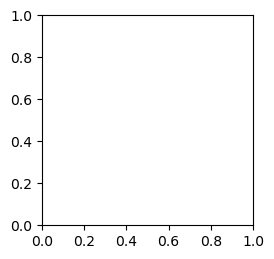

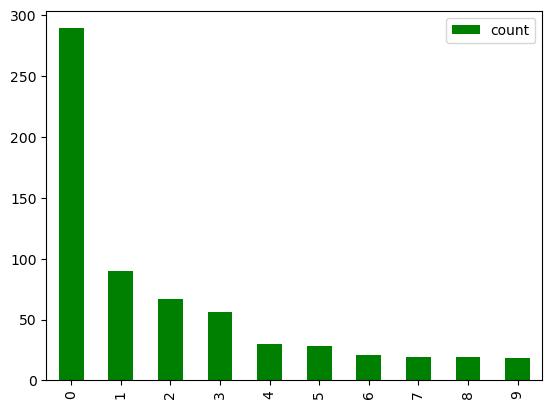

In [143]:
#Bonus (10): Hazırladığınız vizuallardan (maks 4) bir dashboard düzəldin. 4 hissədən ibarət olsun.
plt.figure(figsize=(6,6))

plt.subplot(2,2,1)
a.plot(kind='bar',color='green')
